# Absenteeism forecasts — STL+ETS, any sector

Generate report-ready charts for **any SBI sector** from the cross-validation outputs.

For a chosen sector this notebook produces two images:
1. **Back-test** — forecast vs. actual every quarter (faithful to `stl_ets_predictions.parquet`).
2. **Forward forecast** — the next four quarters beyond the last observation (a genuine refit;
   see note below).

### How to use
- **One sector:** set `SECTOR` in the *Run one sector* cell and run it.
- **Many sectors:** use the *Batch* cell at the bottom (defaults to all sectors).

### Faithfulness notes
- Back-test values come straight from the parquet (`y_true`, `y_pred`); nothing is refit.
- The forward forecast is **not** in the parquet (which ends at the last observed quarter). It
  is produced by refitting STL+ETS on the full corrected series, using the winning correction
  from `stl_ets_best_configs.json` and the winning STL+ETS config from `cv_results.parquet`.
- **No confidence intervals** anywhere (STL+ETS carries none in the export).


In [ ]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates

# --- Global settings ---------------------------------------------------------
COVID_START = pd.Timestamp("2020-03-31")
COVID_END   = pd.Timestamp("2022-06-30")
HIST_START  = "2015-01-01"     # first quarter shown on charts
HORIZON     = 4                # lead time for the back-test forecast line (1..4)
FORWARD_H   = 4                # quarters to forecast beyond the last observation
OUTPUT_DIR  = Path("images"); OUTPUT_DIR.mkdir(exist_ok=True)

# Manual STL+ETS config — used only if cv_results.parquet is unavailable.
MANUAL_CONFIG = dict(stl_seasonal=7, stl_seasonal_deg=1,
                     ets_error="add", ets_trend="add", ets_damped=True)

# Optional manual overrides for chart headers (applied on top of DB titles).
# Chart titles otherwise come from the silver DB (next cell); missing codes
# fall back to "Sector <code>".
SECTOR_TITLE_OVERRIDES = {}    # e.g. {"T001081": "All economic activities"}

def _resolve(name, candidates=("cv_output", ".", "/mnt/user-data/uploads")):
    for d in candidates:
        p = Path(d) / name
        if p.exists():
            return p
    raise FileNotFoundError(f"Could not find {name} in {candidates}")

# Load the CV outputs ONCE.
PRED_PATH = _resolve("stl_ets_predictions.parquet")
CFG_PATH  = _resolve("stl_ets_best_configs.json")
df_pred   = pd.read_parquet(PRED_PATH)
best_cfg  = json.loads(Path(CFG_PATH).read_text())
try:
    CVR_PATH = _resolve("cv_results.parquet")
    df_cvr   = pd.read_parquet(CVR_PATH)
except FileNotFoundError:
    CVR_PATH, df_cvr = None, None

ALL_SECTORS = sorted(set(df_pred["sector_code"]) & set(best_cfg))
print(f"predictions : {PRED_PATH}")
print(f"best configs: {CFG_PATH}")
print(f"cv_results  : {CVR_PATH if CVR_PATH else 'NOT FOUND -> forward forecast uses MANUAL_CONFIG'}")
print(f"{len(ALL_SECTORS)} sectors available")

predictions : cv_output\stl_ets_predictions.parquet
best configs: cv_output\stl_ets_best_configs.json
cv_results  : cv_output\cv_results.parquet
39 sectors available


In [ ]:
# --- SBI titles for chart headers (from the silver DB) -----------------------
# Falls back to "Sector <code>" if the DB / src package isn't importable here.
import os, sys

SECTOR_TITLES = {}
try:
    _root = Path(os.getcwd()).resolve()
    for _ in range(8):                       # put project root on sys.path for `src` imports
        if (_root / "src" / "config.py").exists():
            if str(_root) not in sys.path:
                sys.path.insert(0, str(_root))
            break
        if _root.parent == _root:
            break
        _root = _root.parent

    from src.config import DIR_DB_SILVER
    from src.utils.m_query_database import f_query_database

    _titles_df = f_query_database(
        DIR_DB_SILVER,
        '''SELECT DISTINCT BedrijfskenmerkenSBI2008       AS sbi_code,
                          BedrijfskenmerkenSBI2008_Title AS sbi_title
           FROM "80072ned_silver"''',
        "pandas",
    )
    SECTOR_TITLES = dict(zip(_titles_df["sbi_code"], _titles_df["sbi_title"]))
    print(f"\u2705 loaded {len(SECTOR_TITLES)} SBI titles from the silver DB")
except Exception as exc:
    print(f"\u26a0\ufe0f could not load SBI titles ({type(exc).__name__}: {exc}) \u2014 using sector codes")

SECTOR_TITLES.update(SECTOR_TITLE_OVERRIDES)   # manual overrides win

✅ Query returned 39 rows from silver_data.db as pandas DataFrame


✅ loaded 39 SBI titles from the silver DB


In [ ]:
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from statsmodels.tsa.forecasting.stl import STLForecast

# Palette
GREY_LINE, GREY_LIGHT = "#9E9E9E", "#E0E0E0"
ORANGE_MAIN           = "#E8750A"
TEXT_DARK, TEXT_MID   = "#2D2D2D", "#6B6B6B"

def sector_title(code):
    return SECTOR_TITLES.get(code, f"Sector {code}")

# --- Data accessors (faithful: straight from the predictions parquet) --------
def get_actuals(sector):
    sec = df_pred[df_pred["sector_code"] == sector]
    if sec.empty:
        raise KeyError(f"{sector} not in predictions file")
    return sec.groupby("target_date")["y_true"].first().sort_index().asfreq("QE")

def get_backtest_forecast(sector, horizon):
    sec = df_pred[(df_pred["sector_code"] == sector) & (df_pred["horizon"] == horizon)]
    return sec.set_index("target_date")["y_pred"].sort_index()

# --- Correction builder (mirrors build_correction_variants in the CV script) -
def _seasonal_mean(ts, b_win, a_win, cs=COVID_START, ce=COVID_END):
    ts = ts.sort_index().copy()
    mask = (ts.index >= cs) & (ts.index <= ce)
    out = ts.copy()
    for d in ts.index[mask]:
        same_q = ts.index[(ts.index.quarter == d.quarter) & (~mask)]
        refs = same_q[same_q < cs][-b_win:].union(same_q[same_q > ce][:a_win])
        if len(refs) > 0:
            out[d] = ts[refs].mean()
    return out

def build_corrected_series(ts, label):
    """Reproduce any winning correction label: seasonal_mean|bX_aY / no_correction (+|winsorized)."""
    parts = label.split("|")
    out = ts.sort_index().copy()
    if parts[0] == "seasonal_mean":
        ba = next(p for p in parts if p.startswith("b"))
        b = int(ba.split("_")[0][1:]); a = int(ba.split("_")[1][1:])
        out = _seasonal_mean(out, b, a)
    if "winsorized" in parts:
        out = out.clip(lower=out.quantile(0.05), upper=out.quantile(0.95))
    return out

# --- Winning STL+ETS config: from cv_results.parquet, else MANUAL_CONFIG ------
_CFG_COLS = ["stl_seasonal", "stl_seasonal_deg", "ets_error", "ets_trend", "ets_damped"]

def load_winning_config(sector, correction):
    if df_cvr is None:
        return MANUAL_CONFIG, {"source": "MANUAL_CONFIG"}
    sub = df_cvr[(df_cvr["sbi_code"] == sector) & (df_cvr["correction"] == correction)]
    if sub.empty:
        return MANUAL_CONFIG, {"source": "MANUAL_CONFIG (no matching cv_results rows)"}
    per_fold = sub.sort_values("origin_date").drop_duplicates("origin_date")
    last = per_fold.iloc[-1]
    cfg = dict(stl_seasonal=int(last["stl_seasonal"]),
               stl_seasonal_deg=int(last["stl_seasonal_deg"]),
               ets_error=str(last["ets_error"]),
               ets_trend=(None if str(last["ets_trend"]) in ("None", "nan", "") else str(last["ets_trend"])),
               ets_damped=bool(last["ets_damped"]))
    key = per_fold[_CFG_COLS].astype(str).agg("|".join, axis=1)
    modal_share = float((key == key.iloc[-1]).mean())
    return cfg, {"source": "cv_results.parquet", "n_folds": len(per_fold),
                 "modal_share": round(modal_share, 2)}

# --- Forward forecast: refit on full corrected series, forecast FORWARD_H -----
def forward_forecast(actuals, correction, sector, forward_h=FORWARD_H):
    cfg, info = load_winning_config(sector, correction)
    ts_corr = build_corrected_series(actuals.asfreq("QE"), correction)
    try:
        res = STLForecast(
            ts_corr, model=ETSModel,
            model_kwargs=dict(error=cfg["ets_error"], trend=cfg["ets_trend"],
                              seasonal=None, damped_trend=cfg["ets_damped"]),
            period=4, seasonal=cfg["stl_seasonal"], seasonal_deg=cfg["stl_seasonal_deg"],
            robust=True,
        ).fit()
        idx = pd.date_range(ts_corr.index[-1], periods=forward_h + 1, freq="QE")[1:]
        df_future = pd.DataFrame({"forecast": np.asarray(res.forecast(forward_h))}, index=idx)
        df_future.index.name = "target_date"
        return df_future, cfg, info
    except Exception as exc:
        print(f"   ⚠️ {sector}: forward forecast failed ({exc})")
        return None, cfg, info

# --- Shared axis styling -----------------------------------------------------
def _style_axes(ax):
    for s in ["top", "right", "left"]:
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(GREY_LIGHT); ax.spines["bottom"].set_linewidth(0.8)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.0f%%"))
    ax.tick_params(length=0, colors=TEXT_MID, labelsize=9.5, pad=8)
    ax.grid(axis="y", color=GREY_LIGHT, linewidth=0.5, zorder=0)
    ax.grid(axis="x", visible=False)

def _covid_band(ax):
    ax.axvspan(COVID_START, COVID_END, color=GREY_LIGHT, alpha=0.5, zorder=0)
    ax.text(COVID_START + (COVID_END - COVID_START) / 2, 0.97, "COVID Pandemic",
            color=TEXT_MID, fontsize=9, fontweight="medium", ha="center", va="top",
            transform=ax.get_xaxis_transform())

def _titles(ax, title, subtitle):
    ax.text(0.0, 1.12, title, transform=ax.transAxes, fontsize=16, fontweight="bold",
            color=TEXT_DARK, ha="left", va="bottom")
    ax.text(0.0, 1.04, subtitle, transform=ax.transAxes, fontsize=10.5,
            color=TEXT_MID, ha="left", va="bottom")

In [ ]:
def plot_backtest(sector, horizon=HORIZON, hist_start=HIST_START, show=True):
    correction = best_cfg[sector]
    actuals = get_actuals(sector)
    fc = get_backtest_forecast(sector, horizon)
    df_ts = actuals[actuals.index >= hist_start]
    df_fc = fc[fc.index >= hist_start]
    ov = pd.concat([df_ts.rename("a"), df_fc.rename("f")], axis=1).dropna()
    mae = (ov["a"] - ov["f"]).abs().mean()
    mape = ((ov["a"] - ov["f"]).abs() / ov["a"]).mean() * 100

    fig, ax = plt.subplots(figsize=(14, 5.5))
    fig.patch.set_facecolor("white"); ax.set_facecolor("white")
    _covid_band(ax)
    ax.plot(df_ts.index, df_ts.values, linewidth=2.2, color=GREY_LINE, zorder=2, label="Actual")
    lead = "one year ahead" if horizon == 4 else f"{horizon}q ahead"
    ax.plot(df_fc.index, df_fc.values, linewidth=2.0, color=ORANGE_MAIN, zorder=3,
            marker="o", markersize=3.2, markerfacecolor="white", markeredgecolor=ORANGE_MAIN,
            markeredgewidth=1.0, label=f"Forecast (h={horizon}, {lead})")
    _style_axes(ax)
    leg = ax.legend(loc="upper left", frameon=False, fontsize=9.5, ncol=2, handlelength=1.8)
    for t_ in leg.get_texts(): t_.set_color(TEXT_MID)
    yrs = f"{ov.index.min().year}\u2013{ov.index.max().year}"
    ax.text(0.995, 0.06, f"Back-test accuracy ({yrs}):  MAE {mae:.2f} pp   \u00b7   MAPE {mape:.1f}%",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=9, color=TEXT_MID)
    _titles(ax, f"Sickness absenteeism \u2014 {sector_title(sector)}",
            f"STL+ETS back-test: forecast vs. actual, every quarter  \u00b7  correction: {correction}")
    plt.tight_layout(); plt.subplots_adjust(top=0.80)
    out = OUTPUT_DIR / f"{sector}_backtest_h{horizon}.png"
    plt.savefig(out, dpi=200, bbox_inches="tight", facecolor="white")
    if show: plt.show()
    else: plt.close(fig)
    return out, {"mae": round(float(mae), 3), "mape": round(float(mape), 2)}


def plot_forward(sector, forward_h=FORWARD_H, hist_start=HIST_START, show=True):
    correction = best_cfg[sector]
    actuals = get_actuals(sector)
    df_future, cfg, info = forward_forecast(actuals, correction, sector, forward_h)
    if df_future is None:
        return None, info
    df_ts = actuals[actuals.index >= hist_start]
    last_obs, last_val = actuals.index[-1], float(actuals.iloc[-1])

    fig, ax = plt.subplots(figsize=(14, 5.5))
    fig.patch.set_facecolor("white"); ax.set_facecolor("white")
    _covid_band(ax)
    ax.plot(df_ts.index, df_ts.values, linewidth=2.2, color=GREY_LINE, zorder=2, label="Actual")
    ax.axvline(last_obs, color=GREY_LIGHT, linestyle="--", linewidth=1, zorder=1)
    ax.plot([last_obs, df_future.index[0]], [last_val, df_future["forecast"].iloc[0]],
            color=ORANGE_MAIN, linewidth=1.5, linestyle="--", zorder=3)
    ax.plot(df_future.index, df_future["forecast"], linewidth=2.5, color=ORANGE_MAIN, zorder=4,
            marker="o", markersize=5, markerfacecolor="white", markeredgecolor=ORANGE_MAIN,
            markeredgewidth=1.5, label=f"Forecast (next {forward_h}q)")
    for i, (dt, row) in enumerate(df_future.iterrows()):
        off = pd.DateOffset(weeks=-1) if i == 0 else pd.DateOffset(weeks=2)
        ha = "right" if i == 0 else "left"
        ax.annotate(f"{row['forecast']:.1f}%", xy=(dt, row["forecast"]),
                    xytext=(dt + off, row["forecast"] + 0.35), fontsize=9.5, fontweight="medium",
                    color=ORANGE_MAIN, ha=ha, va="bottom",
                    arrowprops=dict(arrowstyle="-", color=ORANGE_MAIN, lw=0.8, shrinkA=0, shrinkB=3))
    _style_axes(ax)
    leg = ax.legend(loc="upper left", frameon=False, fontsize=9.5, ncol=2, handlelength=1.8)
    for t_ in leg.get_texts(): t_.set_color(TEXT_MID)
    _titles(ax, f"Sickness absenteeism \u2014 {sector_title(sector)}",
            f"STL+ETS forecast, next {forward_h} quarters beyond last observation  \u00b7  correction: {correction}")
    plt.tight_layout(); plt.subplots_adjust(top=0.80)
    out = OUTPUT_DIR / f"{sector}_forward_{forward_h}q.png"
    plt.savefig(out, dpi=200, bbox_inches="tight", facecolor="white")
    if show: plt.show()
    else: plt.close(fig)
    return out, {"forecast": df_future, "config": cfg, "config_info": info}


def run_sector(sector, make_backtest=True, make_forward=True, show=True):
    """Generate the chart(s) for one sector and return a small result dict."""
    if sector not in best_cfg:
        print(f"⚠️ {sector}: no winning correction in best_configs — skipping"); return None
    res = {"sector": sector, "correction": best_cfg[sector]}
    if make_backtest:
        path, acc = plot_backtest(sector, show=show); res["backtest_png"] = path; res["accuracy"] = acc
    if make_forward:
        path, fwd = plot_forward(sector, show=show)
        res["forward_png"] = path
        if path is not None:
            res["forecast"] = fwd["forecast"]; res["config"] = fwd["config"]; res["config_info"] = fwd["config_info"]
    return res

## Run one sector
Set `SECTOR` and run. Both images are written to `images/`.

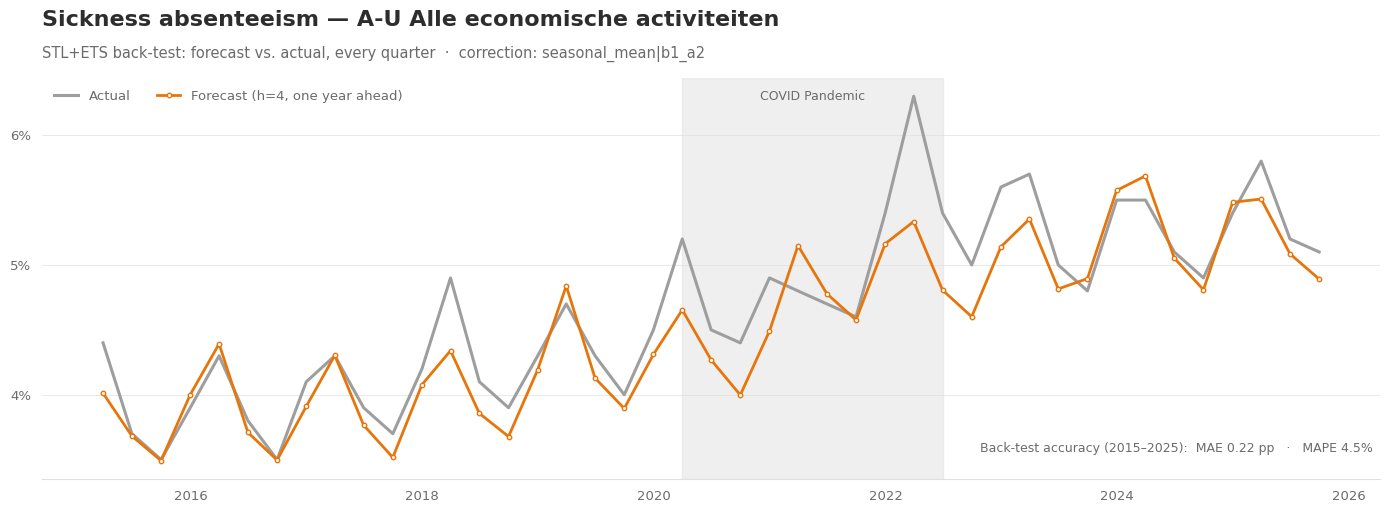

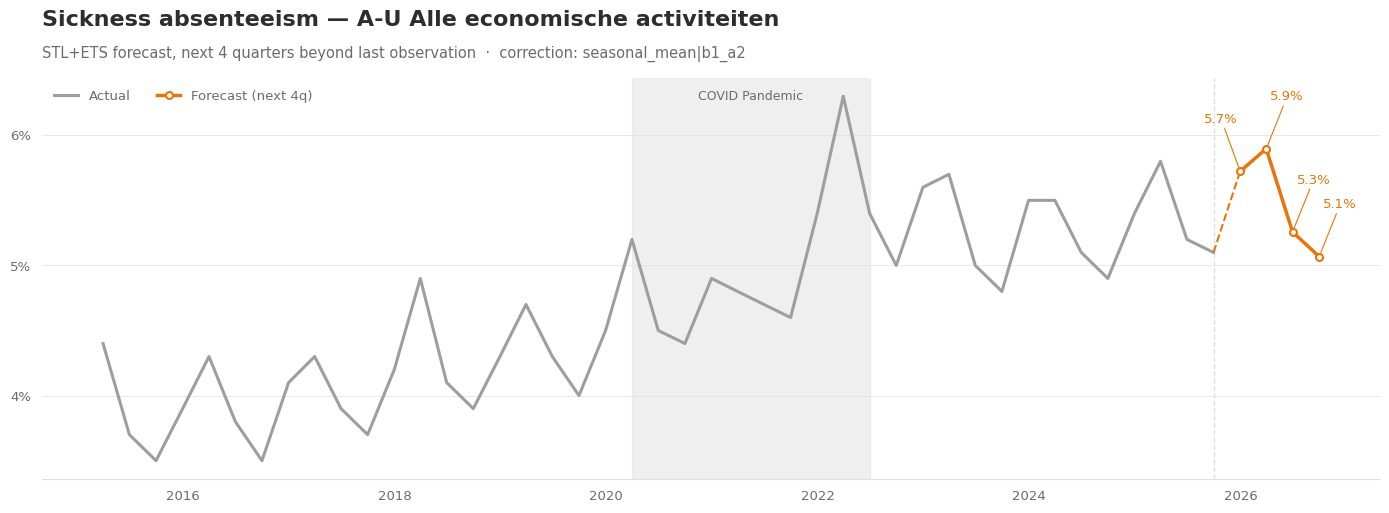

correction: seasonal_mean|b1_a2 | accuracy: {'mae': 0.221, 'mape': 4.5}
config provenance: {'source': 'cv_results.parquet', 'n_folds': 64, 'modal_share': 0.72}


,forecast
target_date,
2025-12-31,5.72
2026-03-31,5.90
2026-06-30,5.26
2026-09-30,5.07


In [ ]:
SECTOR = "T001081"          # <-- change to any code in ALL_SECTORS

result = run_sector(SECTOR, make_backtest=True, make_forward=True, show=True)
print("correction:", result["correction"], "| accuracy:", result.get("accuracy"))
print("config provenance:", result.get("config_info"))
if "forecast" in result:
    display(result["forecast"].round(2))

## Variant — actual vs. h=1 and h=4 on one chart
Overlays the best-case (one-quarter-ahead) and the year-ahead forecast so the report shows
both. The dark line (h=1) hugs the actuals; the lighter line (h=4) is the harder, year-ahead
test and ends one year earlier (last origin is 2024 Q3, so h=1 has no 2025 forecasts).

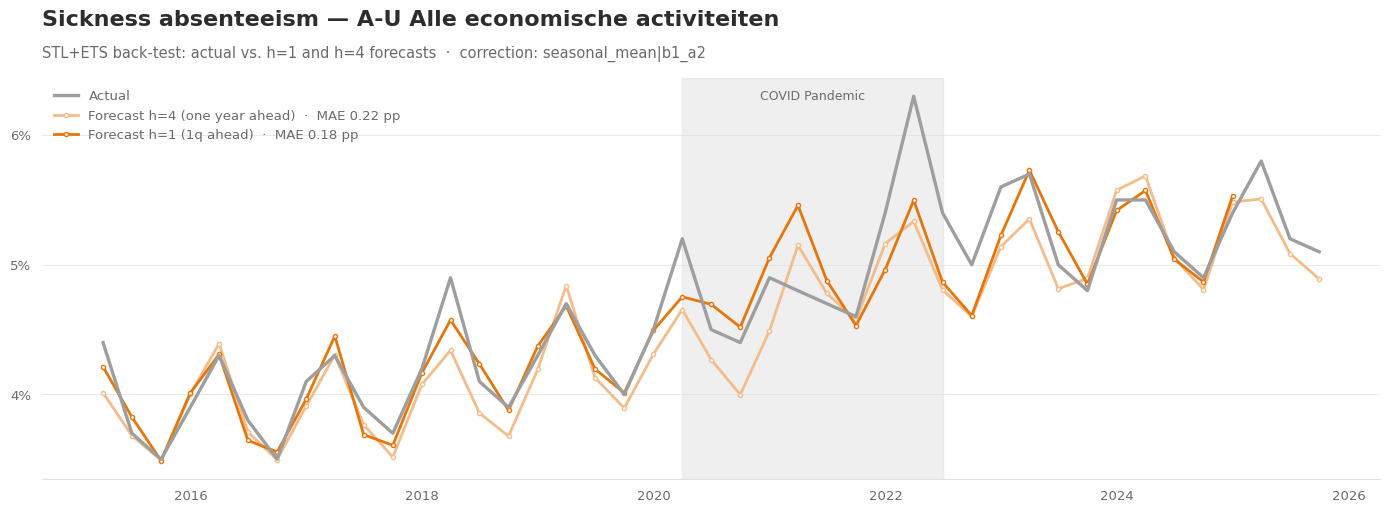

WindowsPath('images/T001081_overlay_h1_h4.png')

In [ ]:
def plot_overlay_h1_h4(sector, horizons=(1, 4), hist_start=HIST_START, show=True):
    """Overlay the actual series against forecasts at two horizons (default h=1 and h=4)."""
    correction = best_cfg[sector]
    actuals = get_actuals(sector)
    df_ts = actuals[actuals.index >= hist_start]

    colors = {1: "#E8750A", 2: "#EC8A2E", 3: "#F0A35C", 4: "#F4BC8A"}  # darker = shorter lead
    series = {}
    for h in horizons:
        fc = get_backtest_forecast(sector, h)
        fc = fc[fc.index >= hist_start]
        ov = pd.concat([df_ts.rename("a"), fc.rename("f")], axis=1).dropna()
        series[h] = (fc, (ov["a"] - ov["f"]).abs().mean())

    fig, ax = plt.subplots(figsize=(14, 5.5))
    fig.patch.set_facecolor("white"); ax.set_facecolor("white")
    _covid_band(ax)
    ax.plot(df_ts.index, df_ts.values, linewidth=2.4, color=GREY_LINE, zorder=10, label="Actual")
    for h in sorted(horizons, reverse=True):           # draw longer leads first, shortest on top
        fc, mae = series[h]
        lead = "1q ahead" if h == 1 else ("one year ahead" if h == 4 else f"{h}q ahead")
        ax.plot(fc.index, fc.values, linewidth=2.0, color=colors.get(h, ORANGE_MAIN),
                zorder=10 - h, marker="o", markersize=3.0, markerfacecolor="white",
                markeredgecolor=colors.get(h, ORANGE_MAIN), markeredgewidth=1.0,
                label=f"Forecast h={h} ({lead})  \u00b7  MAE {mae:.2f} pp")
    _style_axes(ax)
    leg = ax.legend(loc="upper left", frameon=False, fontsize=9.5, ncol=1, handlelength=1.8)
    for t_ in leg.get_texts(): t_.set_color(TEXT_MID)
    _titles(ax, f"Sickness absenteeism \u2014 {sector_title(sector)}",
            f"STL+ETS back-test: actual vs. {' and '.join('h=%d' % h for h in sorted(horizons))} forecasts"
            f"  \u00b7  correction: {correction}")
    plt.tight_layout(); plt.subplots_adjust(top=0.80)
    tag = "_".join(f"h{h}" for h in sorted(horizons))
    out = OUTPUT_DIR / f"{sector}_overlay_{tag}.png"
    plt.savefig(out, dpi=200, bbox_inches="tight", facecolor="white")
    if show: plt.show()
    else: plt.close(fig)
    return out

plot_overlay_h1_h4(SECTOR)              # uses SECTOR from the run-one-sector cell

## Variant — chosen method vs. current baseline
Overlays actuals (grey), the chosen STL+ETS forecast at h=1 (dark orange), and the **current
production baseline** — the seasonal moving average (blue). The baseline's per-quarter
predictions are read from the **gold DB** (`prediction_baseline_total` / `_sbi` / `_compsize`),
which stores one `baseline_prediction` per sector per quarter. Set `GOLD_DB` if it can't be
auto-located; if the DB is missing the blue line is skipped and the chart still renders.

In [ ]:
# \u2500\u2500 Current-method BASELINE (seasonal moving average) from the GOLD DB \u2500\u2500\u2500\u2500\u2500\u2500
# The gold DB stores one baseline_prediction per sector per quarter across these tables.
import os, sqlite3

BASELINE_TABLES = ["prediction_baseline_total",
                   "prediction_baseline_sbi",
                   "prediction_baseline_compsize"]

def _resolve_gold_db():
    """Locate gold_data.db: an explicit GOLD_DB -> src.config.DIR_DB_GOLD ->
    <project_root>/data/3_gold/gold_data.db -> a few relative guesses."""
    try:
        if GOLD_DB:
            return Path(GOLD_DB)
    except NameError:
        pass
    try:
        from src.config import DIR_DB_GOLD
        return Path(DIR_DB_GOLD)
    except Exception:
        pass
    here = Path(os.getcwd()).resolve()
    for base in [here, *here.parents]:
        cand = base / "data" / "3_gold" / "gold_data.db"
        if cand.exists():
            return cand
    for cand in ("data/3_gold/gold_data.db", "../data/3_gold/gold_data.db",
                 "../../data/3_gold/gold_data.db", "gold_data.db"):
        if Path(cand).exists():
            return Path(cand)
    return None

def _load_baseline_preds():
    db = _resolve_gold_db()
    if db is None or not Path(db).exists():
        print("\u26a0\ufe0f gold DB not found \u2014 set GOLD_DB; baseline (blue) line will be skipped")
        return None
    frames = []
    with sqlite3.connect(str(db)) as con:
        existing = {r[0] for r in con.execute(
            "SELECT name FROM sqlite_master WHERE type='table'")}
        for t in BASELINE_TABLES:
            if t not in existing:
                continue
            cols = {r[1] for r in con.execute(f'PRAGMA table_info("{t}")')}
            if not {"sbi_code", "period_enddate", "baseline_prediction"} <= cols:
                continue
            sel = ["sbi_code", "period_enddate", "baseline_prediction"]
            if "absenteeism_perc" in cols:
                sel.append("absenteeism_perc")
            frames.append(pd.read_sql(f'SELECT {", ".join(sel)} FROM "{t}"', con))
    if not frames:
        print("\u26a0\ufe0f no prediction_baseline_* tables in gold DB \u2014 baseline skipped")
        return None
    df = pd.concat(frames, ignore_index=True)
    df["sbi_code"] = df["sbi_code"].astype(str)
    df["period_enddate"] = pd.to_datetime(df["period_enddate"], errors="coerce")
    df["baseline_prediction"] = pd.to_numeric(df["baseline_prediction"], errors="coerce")
    df = df.dropna(subset=["period_enddate", "baseline_prediction"])
    print(f"\u2705 baseline loaded from gold DB: {len(df):,} rows, "
          f"{df['sbi_code'].nunique()} sectors")
    return df

baseline_preds = _load_baseline_preds()

def get_baseline_series(sector):
    """Per-quarter baseline (seasonal moving average) for one sector, from the gold DB."""
    if baseline_preds is None or baseline_preds.empty:
        return None
    b = baseline_preds[baseline_preds["sbi_code"].astype(str) == str(sector)].copy()
    if b.empty:
        return None
    # one value per quarter (dedupe defensively if a code appears in >1 table)
    s = b.groupby("period_enddate")["baseline_prediction"].mean().sort_index()
    s.index = pd.DatetimeIndex(s.index)
    return s

✅ baseline loaded from gold DB: 989 rows, 23 sectors


   baseline: 43 pts, 2015-03-31 -> 2025-09-30


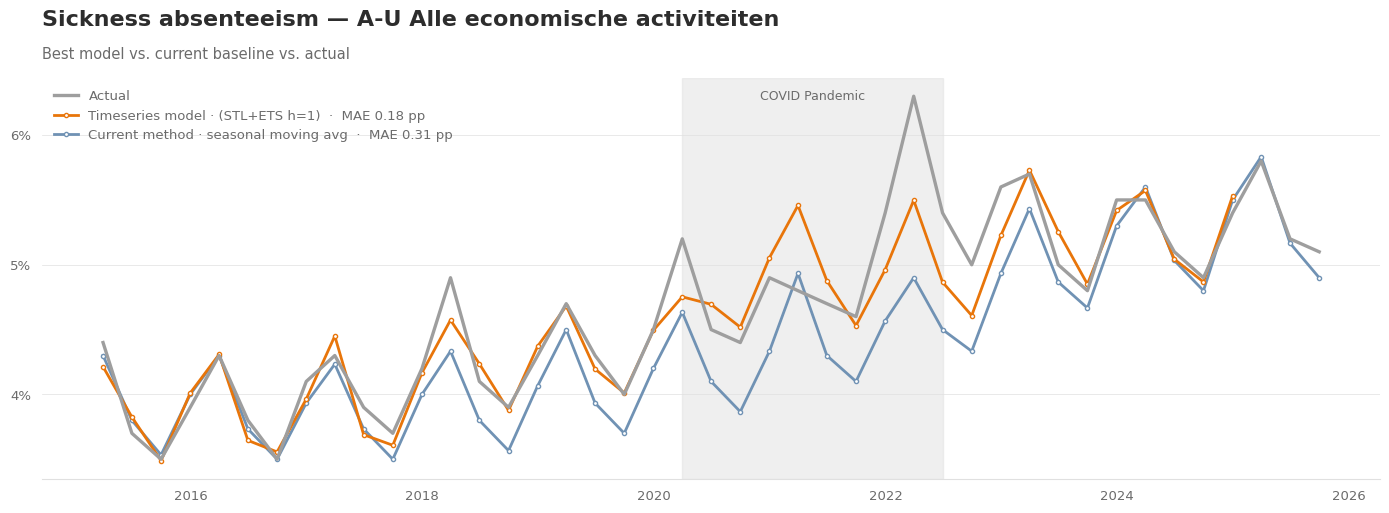

WindowsPath('images/T001081_vs_baseline_h1.png')

In [ ]:
def plot_vs_baseline(sector, horizon=1, hist_start=HIST_START, show=True):
    """Actual vs. chosen STL+ETS (short-lead) vs. current baseline (seasonal moving avg).

    The baseline (blue) is drawn over whatever window it was evaluated on; the two
    MAEs are computed on the SAME window (where the baseline exists) so the numbers
    are comparable.
    """
    correction = best_cfg[sector]
    actuals = get_actuals(sector)
    df_ts = actuals[actuals.index >= hist_start]
    chosen = get_backtest_forecast(sector, horizon)
    chosen = chosen[chosen.index >= hist_start]
    base = get_baseline_series(sector)
    if base is not None:
        base = base[base.index >= hist_start]
        print(f"   baseline: {len(base)} pts, {base.index.min().date()} -> {base.index.max().date()}")
    else:
        print("   baseline: none for this sector (blue line skipped)")

    # Common scoring window: where actual + chosen (+ baseline, if present) overlap.
    common = df_ts.index.intersection(chosen.index)
    if base is not None and len(base):
        common = common.intersection(base.index)

    def _mae(s):
        if s is None or not len(common):
            return float("nan")
        ov = pd.concat([df_ts, s], axis=1, keys=["a", "f"]).reindex(common).dropna()
        return (ov["a"] - ov["f"]).abs().mean() if len(ov) else float("nan")

    chosen_mae, base_mae = _mae(chosen), _mae(base)
    win = f"{common.min().year}\u2013{common.max().year}" if len(common) else "n/a"

    BLUE = "#7092B4"
    fig, ax = plt.subplots(figsize=(14, 5.5))
    fig.patch.set_facecolor("white"); ax.set_facecolor("white")
    _covid_band(ax)

    # Actual drawn on top (zorder), then chosen, then baseline; legend in this order.
    ax.plot(df_ts.index, df_ts.values, linewidth=2.4, color=GREY_LINE, zorder=5, label="Actual")
    ax.plot(chosen.index, chosen.values, linewidth=2.0, color=ORANGE_MAIN, zorder=4,
            marker="o", markersize=3.0, markerfacecolor="white", markeredgecolor=ORANGE_MAIN,
            markeredgewidth=1.0,
            label=f"Timeseries model \u00b7 (STL+ETS h={horizon})  \u00b7  MAE {chosen_mae:.2f} pp")
    if base is not None and len(base):
        ax.plot(base.index, base.values, linewidth=2.0, color=BLUE, zorder=3,
                marker="o", markersize=3.0, markerfacecolor="white", markeredgecolor=BLUE,
                markeredgewidth=1.0,
                label=f"Current method \u00b7 seasonal moving avg  \u00b7  MAE {base_mae:.2f} pp")

    _style_axes(ax)
    leg = ax.legend(loc="upper left", frameon=False, fontsize=9.5, ncol=1, handlelength=1.8)
    for t_ in leg.get_texts(): t_.set_color(TEXT_MID)
    _titles(ax, f"Sickness absenteeism \u2014 {sector_title(sector)}",
            f"Best model vs. current baseline vs. actual")
    plt.tight_layout(); plt.subplots_adjust(top=0.80)
    out = OUTPUT_DIR / f"{sector}_vs_baseline_h{horizon}.png"
    plt.savefig(out, dpi=200, bbox_inches="tight", facecolor="white")
    if show: plt.show()
    else: plt.close(fig)
    return out

plot_vs_baseline(SECTOR)          # uses SECTOR from the run-one-sector cell

## Batch — generate images for many sectors
Runs silently (no inline display) and writes two PNGs per sector to `images/`.
Edit `SECTORS_TO_RUN` to a subset, or leave as `ALL_SECTORS` for everything.

In [ ]:
SECTORS_TO_RUN = ALL_SECTORS      # e.g. ["T001081", "300003", "350000"]

summary = []
for i, code in enumerate(SECTORS_TO_RUN, 1):
    print(f"[{i}/{len(SECTORS_TO_RUN)}] {code} ({best_cfg.get(code, '?')})")
    try:
        r = run_sector(code, make_backtest=True, make_forward=True, show=False)
        if r:
            summary.append({"sector": code, "correction": r["correction"],
                            "mae": r.get("accuracy", {}).get("mae"),
                            "mape": r.get("accuracy", {}).get("mape"),
                            "forward_ok": "forecast" in r})
    except Exception as exc:
        print(f"   ⚠️ {code} failed: {exc}")
        summary.append({"sector": code, "correction": best_cfg.get(code), "forward_ok": False})

summary_df = pd.DataFrame(summary)
print(f"\nDone. PNGs in {OUTPUT_DIR.resolve()}")
display(summary_df)

[1/39] 300003 (no_correction|winsorized)
[2/39] 300007 (no_correction|winsorized)
[3/39] 300013 (seasonal_mean|b1_a1)
[4/39] 301000 (no_correction|winsorized)
[5/39] 305700 (seasonal_mean|b1_a3|winsorized)
[6/39] 307500 (seasonal_mean|b1_a3|winsorized)
[7/39] 307610 (seasonal_mean|b1_a3|winsorized)
[8/39] 317105 (seasonal_mean|b1_a2|winsorized)
[9/39] 320005 (seasonal_mean|b1_a2|winsorized)
[10/39] 328110 (seasonal_mean|b1_a3|winsorized)
[11/39] 346600 (seasonal_mean|b2_a3|winsorized)
[12/39] 348000 (seasonal_mean|b1_a2|winsorized)
[13/39] 350000 (no_correction|winsorized)
[14/39] 354200 (no_correction|winsorized)
[15/39] 354300 (no_correction)
[16/39] 356900 (seasonal_mean|b1_a3)
[17/39] 371600 (no_correction|winsorized)
[18/39] 383100 (no_correction|winsorized)
[19/39] 383200 (no_correction|winsorized)
[20/39] 389100 (no_correction)
[21/39] 391600 (seasonal_mean|b2_a2|winsorized)
[22/39] 396300 (seasonal_mean|b3_a1)
[23/39] 402000 (seasonal_mean|b1_a3|winsorized)
[24/39] 403300 (seas

,sector,correction,mae,mape,forward_ok
0,300003,no_correction|winsorized,0.281,5.16,True
1,300007,no_correction|winsorized,0.213,5.19,True
2,300013,seasonal_mean|b1_a1,0.257,4.29,True
3,301000,no_correction|winsorized,0.317,9.85,True
4,305700,seasonal_mean|b1_a3|winsorized,0.341,7.86,True
5,307500,seasonal_mean|b1_a3|winsorized,0.273,4.68,True
6,307610,seasonal_mean|b1_a3|winsorized,0.334,6.09,True
7,317105,seasonal_mean|b1_a2|winsorized,0.535,10.39,True
8,320005,seasonal_mean|b1_a2|winsorized,0.366,6.63,True
9,328110,seasonal_mean|b1_a3|winsorized,0.256,5.24,True
